# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [8]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
print(users.isna().sum())
print()
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [14]:
usage[['id',
       'user_id',
       'duration',
       'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [15]:
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\n{col}")
    print(users[col].value_counts(dropna=False))



city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` ...
- La columna `plan` ...

In [16]:

usage["type"].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
¿En qué columnas encontraste valores inválidos o sentinels?
- En la columna city del dataset users se identificó el valor "?", el cual corresponde a un sentinel y no representa una ciudad válida. Además, la misma columna contiene valores nulos (NaN).
- Las columnas plan y type únicamente presentan categorías válidas (Basico, Premium, call y text), por lo que no se detectaron valores inválidos.
- En las columnas numéricas exploradas (user_id, id, duration y length) no se observaron sentinels evidentes como -999 o valores imposibles durante la revisión inicial.

¿Qué acción tomarías?
- Reemplazar el valor "?" de la columna city por pd.NA, unificando todos los datos faltantes bajo un mismo formato para facilitar su tratamiento posterior.
- Mantener sin modificaciones las columnas plan y type, ya que contienen únicamente categorías válidas.
- Continuar revisando las columnas numéricas en los siguientes pasos para confirmar si existen valores atípicos o inconsistentes que requieran limpieza adicional.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")

In [18]:
usage["date"] = pd.to_datetime(usage["date"], errors="coerce")

In [19]:
users["reg_date"].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, La columna reg_date fue convertida correctamente al tipo datetime. La revisión de los años registrados muestra que la mayoría de las fechas pertenecen al periodo esperado (2022–2024); sin embargo, se identificaron 40 registros correspondientes al año 2026. Dado que el proyecto establece que la información solo está disponible hasta 2024, estas fechas se consideran fuera de rango y deberán tratarse como valores inválidos durante la etapa de limpieza para evitar sesgos en el análisis temporal.

In [20]:
usage["date"].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date`, La columna date fue convertida correctamente al tipo datetime. La revisión de los años registrados muestra que todas las fechas válidas corresponden al año 2024, periodo definido para el análisis del proyecto. No se identifican años futuros ni fechas fuera de rango; únicamente permanecen algunos valores faltantes (NaT) derivados de registros con fechas ausentes, los cuales serán tratados posteriormente según su impacto en el análisis.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? 
La revisión de las columnas de fecha muestra dos situaciones distintas. En reg_date se identificaron 40 registros correspondientes al año 2026, el cual está fuera del periodo definido para el proyecto (hasta 2024), por lo que estas fechas se consideran inválidas y se recomienda convertirlas en valores nulos (NaT) para evitar que afecten los análisis temporales. Por otro lado, la columna date únicamente contiene registros válidos del año 2024, sin evidencia de años futuros o inconsistentes. Los valores faltantes presentes en esta columna se mantendrán para su evaluación durante la etapa de limpieza de datos.

- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users["age"] != -999, "age"].median()

users["age"] = users["age"].replace(-999, age_mediana)

# Verificar cambios
users["age"].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [23]:
# Marcar fechas futuras como NA para reg_date

users.loc[
    users["reg_date"].dt.year > 2024,
    "reg_date"
] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.value_counts(dropna=False)


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
usage.groupby("type")["duration"].apply(lambda x: x.isna().mean())


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [25]:
usage.groupby("type")["length"].apply(lambda x: x.isna().mean())


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

La revisión de los valores faltantes confirma que las ausencias en duration y length dependen directamente de la variable type. Los registros de tipo text presentan prácticamente todos los valores faltantes en duration, mientras que los registros de tipo call presentan prácticamente todos los valores faltantes en length. Esto demuestra que los valores ausentes corresponden a un caso de Missing At Random (MAR), ya que dependen del tipo de actividad registrada y no de errores de captura. En consecuencia, no se recomienda imputar ni eliminar estos valores, pues representan correctamente la naturaleza de cada tipo de interacción y conservarlos evita introducir información artificial en el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
    .agg({
        "is_text": "sum",
        "is_call": "sum",
        "duration": "sum"
    })
    .reset_index()
)

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

usage_agg.head(3)

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:

user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
user_profile[
    [
        "age",
        "cant_mensajes",
        "cant_llamadas",
        "cant_minutos_llamada"
    ]
].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
user_profile["plan"].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

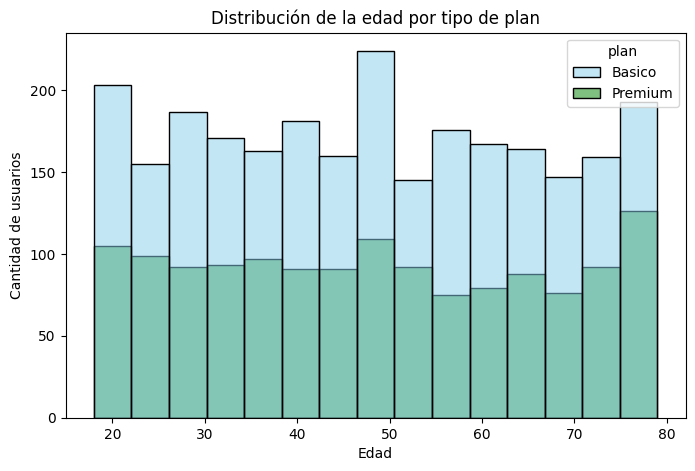

In [31]:

plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=15
)

plt.title("Distribución de la edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")

plt.show()

💡Insights: 
- Se analizó la distribución de edades de los usuarios diferenciando entre los planes Básico y Premium. Ambos planes presentan una distribución relativamente uniforme a lo largo del rango de edades (18 a 79 años), sin evidencias de un sesgo pronunciado ni concentraciones exclusivas en algún grupo etario. El plan Básico muestra un mayor número de usuarios en todos los rangos, lo cual es consistente con su mayor participación dentro de la base de clientes. En conjunto, los resultados sugieren que la edad no parece ser un factor determinante en la elección del plan, por lo que será necesario analizar variables de comportamiento de uso para identificar diferencias más relevantes entre los segmentos.

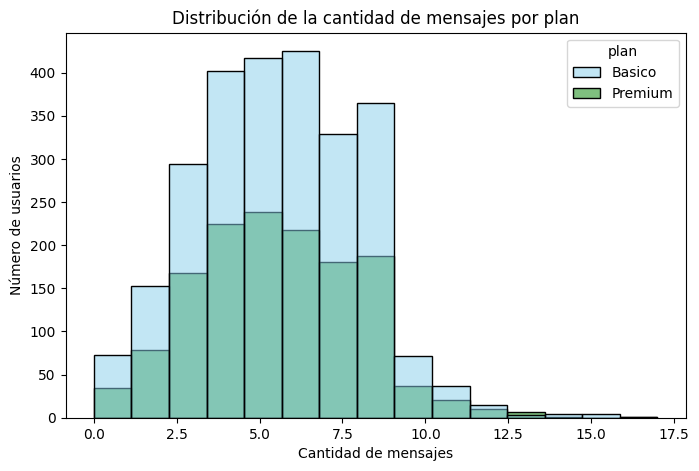

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    bins=15,
    palette=["skyblue", "green"]
)

plt.title("Distribución de la cantidad de mensajes por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Número de usuarios")

plt.show()


💡Insights: 
- La distribución de la cantidad de mensajes muestra que la mayoría de los usuarios envía entre 3 y 8 mensajes durante el periodo analizado. El plan Básico concentra un mayor número de usuarios en todos los rangos, lo que es consistente con su mayor participación dentro de la base de clientes. La distribución presenta un ligero sesgo hacia la derecha, indicando la existencia de un pequeño grupo de usuarios con un uso considerablemente mayor de mensajes, aunque sin representar el comportamiento típico de la mayoría de los clientes.

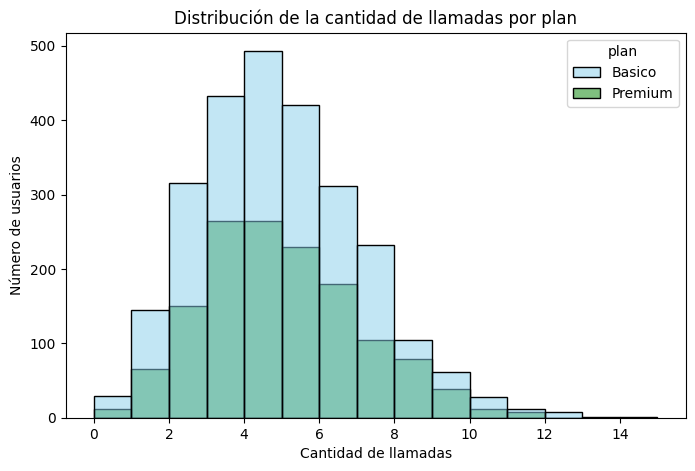

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    bins=15,
    palette=["skyblue", "green"]
)

plt.title("Distribución de la cantidad de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Número de usuarios")

plt.show()


💡Insights: 
- La mayoría de los usuarios realiza entre 3 y 6 llamadas durante el periodo analizado, mientras que un número reducido presenta una frecuencia considerablemente mayor. No se observan diferencias importantes en el patrón de llamadas entre los planes Básico y Premium, más allá del mayor volumen de usuarios pertenecientes al plan Básico. La distribución presenta un ligero sesgo hacia la derecha, lo que sugiere la presencia de algunos usuarios con un comportamiento de uso superior al promedio.

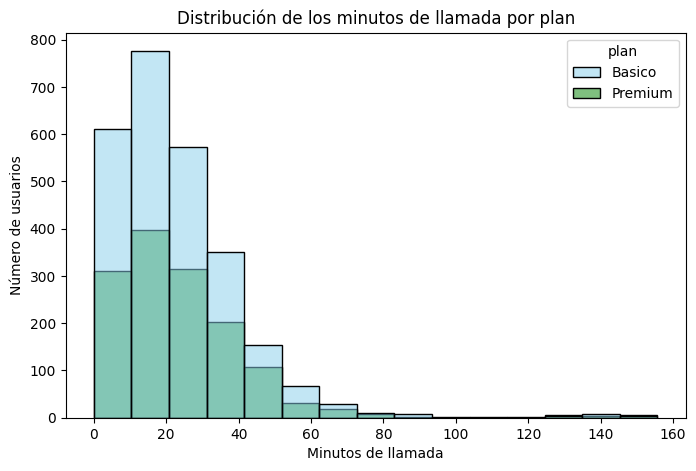

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    bins=15,
    palette=["skyblue", "green"]
)

plt.title("Distribución de los minutos de llamada por plan")
plt.xlabel("Minutos de llamada")
plt.ylabel("Número de usuarios")

plt.show()


💡Insights: 
- La distribución de los minutos de llamada muestra una fuerte concentración de usuarios entre 10 y 30 minutos, seguida por una disminución progresiva de la frecuencia conforme aumenta el tiempo de conversación. Se observa una cola larga hacia la derecha, indicando la existencia de usuarios con un consumo excepcionalmente alto de minutos. Estos registros podrían corresponder a clientes intensivos o representar posibles valores atípicos, por lo que será necesario analizarlos mediante boxplots y el método IQR antes de decidir cualquier tratamiento.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

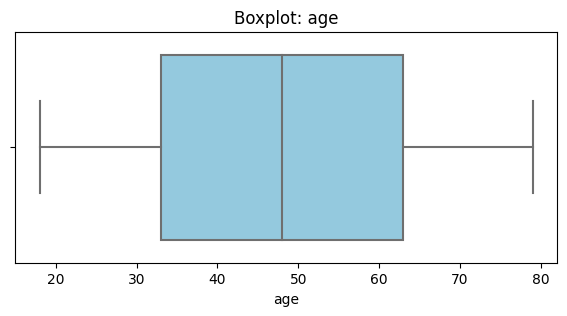

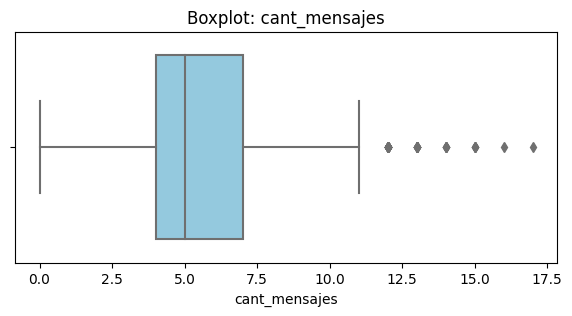

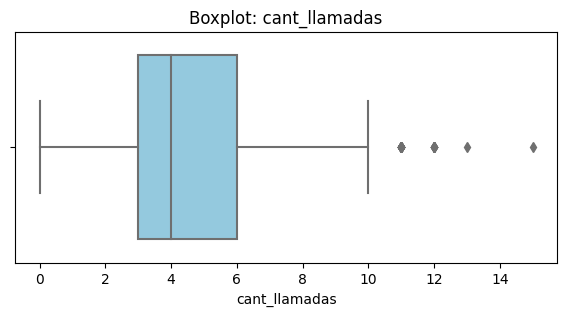

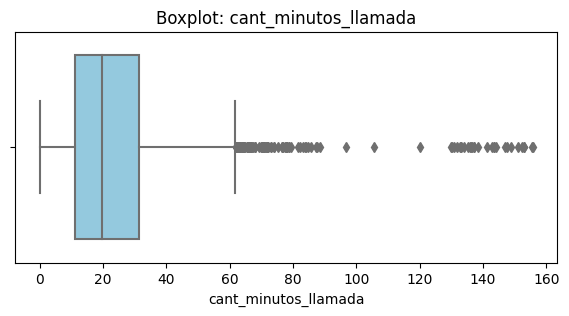

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:

    plt.figure(figsize=(7,3))

    sns.boxplot(
        x=user_profile[col],
        color="skyblue"
    )

    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)

    plt.show()

💡Insights: 
- Age: La variable age no presenta valores atípicos visibles. La distribución de edades es estable y el rango observado (18 a 79 años) corresponde a valores plausibles para la población de clientes, por lo que no se requiere ningún tratamiento adicional.
- cant_mensajes: La variable cant_mensajes presenta algunos valores atípicos por encima del límite superior del boxplot. Sin embargo, estos registros representan clientes con un uso intensivo del servicio y no evidencian errores de captura. Se recomienda mantener estos valores, ya que aportan información relevante sobre diferentes patrones de consumo.
- cant_llamadas: La variable cant_llamadas presenta algunos valores extremos correspondientes a usuarios que realizan un mayor número de llamadas que la mayoría. Dado que estos valores son consistentes con un comportamiento de uso intensivo y no representan errores evidentes, se recomienda conservarlos para el análisis.
- cant_minutos_llamada: La variable cant_minutos_llamada presenta una cantidad considerable de valores atípicos concentrados en la parte superior de la distribución. Estos registros probablemente corresponden a usuarios con un consumo intensivo del servicio y representan un comportamiento válido desde la perspectiva del negocio. Por esta razón, se recomienda mantener estos valores durante el análisis, ya que permiten identificar segmentos de alto consumo y apoyar futuras estrategias comerciales.

In [37]:

columnas_limites = [
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f"\nVariable: {col}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Máximo observado: {user_profile[col].max():.2f}")


Variable: cant_mensajes
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite superior: 11.50
Máximo observado: 17.00

Variable: cant_llamadas
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite superior: 10.50
Máximo observado: 15.00

Variable: cant_minutos_llamada
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite superior: 61.86
Máximo observado: 155.69


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se recomienda mantener los valores atípicos identificados en cant_mensajes, ya que representan usuarios con un mayor nivel de actividad y no evidencian errores de captura. Estos registros permiten analizar distintos patrones de comportamiento entre los clientes.
- cant_llamadas: Los valores extremos observados en cant_llamadas corresponden a usuarios con un mayor volumen de llamadas, pero permanecen dentro de un rango razonable para el contexto del negocio. Se recomienda conservarlos durante el análisis.
- cant_minutos_llamada: Aunque cant_minutos_llamada presenta numerosos valores atípicos, estos representan clientes con un consumo intensivo del servicio y constituyen información valiosa para ConnectaTel. Se recomienda mantenerlos, ya que permiten identificar segmentos de alto consumo y diseñar estrategias comerciales.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
import numpy as np

user_profile["grupo_uso"] = np.where(
    (user_profile["cant_llamadas"] < 5) &
    (user_profile["cant_mensajes"] < 5),
    "Bajo uso",
    np.where(
        (user_profile["cant_llamadas"] < 10) &
        (user_profile["cant_mensajes"] < 10),
        "Uso medio",
        "Alto uso"
    )
)


In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
user_profile["grupo_edad"] = np.where(
    user_profile["age"] < 30,
    "Joven",
    np.where(
        user_profile["age"] < 60,
        "Adulto",
        "Adulto Mayor"
    )
)


In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

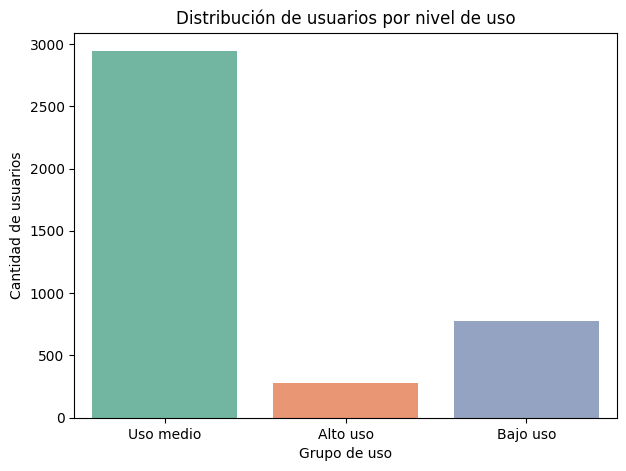

In [44]:

plt.figure(figsize=(7,5))

sns.countplot(
    data=user_profile,
    x="grupo_uso",
    palette="Set2"
)

plt.title("Distribución de usuarios por nivel de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()


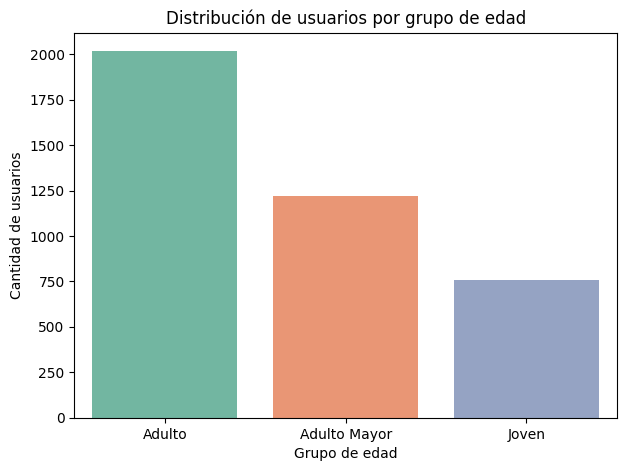

In [45]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=user_profile,
    x="grupo_edad",
    palette="Set2"
)

plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 

- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
  
City tenía 469 valores nulos (11.73 %) y 96 sentinels ("?"), que fueron convertidos a pd.NA.
Churn_date tenía 3534 valores nulos (88.35 %), probablemente correspondientes a clientes activos.
Reg_date contenía 40 fechas del año 2026, las cuales fueron reemplazadas por NaT.
Duration y length presentaban 55.19 % y 44.74 % de valores nulos, respectivamente, confirmándose como un caso MAR, por lo que se mantuvieron.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

  
Se identificaron tres grupos de uso (Bajo, Medio y Alto) y tres grupos de edad (Joven, Adulto y Adulto Mayor). La mayoría de los clientes pertenece al grupo Uso medio y al grupo Adulto.
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Los clientes de Alto uso son los más valiosos porque consumen más llamadas, mensajes y minutos, representando una oportunidad para planes premium y estrategias de fidelización.

  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Se encontraron outliers en cant_mensajes, cant_llamadas y especialmente en cant_minutos_llamada. Se decidió conservarlos porque representan usuarios con alto consumo y no errores en los datos.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Crear planes premium para clientes de Alto uso.
Incentivar a los usuarios de Uso medio a migrar a planes superiores.
Diseñar ofertas dirigidas a Adultos, el segmento predominante.
Desarrollar estrategias para atraer más usuarios Jóvenes.


✍️ **Escribe aquí tu análisis ejecutivo:**
El análisis muestra que la mayoría de los clientes pertenece al segmento de Uso medio y al grupo Adulto, lo que indica un patrón de consumo moderado dentro de la base de usuarios de ConnectaTel. Por otro lado, los clientes de Alto uso constituyen un segmento más reducido, pero con un alto potencial comercial debido a su mayor consumo de llamadas, mensajes y minutos. Estos resultados sugieren que la empresa puede fortalecer sus estrategias de fidelización mediante planes premium dirigidos a usuarios intensivos e incentivar la migración de los clientes de Uso medio hacia ofertas de mayor valor. Asimismo, el predominio de clientes adultos indica que las campañas comerciales deberían enfocarse principalmente en este segmento, sin dejar de desarrollar estrategias para incrementar la participación de usuarios jóvenes.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores nulos y sentinels en las columnas city, churn_date, duration y length, además de 40 fechas fuera del rango del análisis (año 2026), las cuales fueron corregidas o tratadas según su naturaleza.
- Los valores faltantes en duration y length se confirmaron como un caso MAR (Missing At Random), por lo que se conservaron al depender del tipo de actividad (call o text).


🔍 **Segmentos por Edad**
- El segmento predominante corresponde a Adultos, seguido por Adultos Mayores; los Jóvenes representan la menor proporción de clientes.
- La distribución sugiere que la oferta actual está orientada principalmente a una población adulta.


📊 **Segmentos por Nivel de Uso**

- La mayoría de los clientes pertenece al grupo Uso medio, mientras que el grupo Alto uso representa una proporción menor, pero con un consumo significativamente superior.
- Los usuarios de Alto uso constituyen un segmento estratégico por su mayor utilización de llamadas, mensajes y minutos.


➡️ Esto sugiere que ConnectaTel puede incrementar el valor de su cartera incentivando a los usuarios de Uso medio a migrar hacia planes superiores y fortaleciendo la fidelización de los clientes de Alto uso.
El predominio de clientes adultos indica que las estrategias comerciales deben enfocarse principalmente en este segmento, sin dejar de desarrollar iniciativas para atraer usuarios jóvenes.


💡 **Recomendaciones**
- Crear planes premium y beneficios exclusivos para clientes de Alto uso.
- Diseñar campañas para convertir usuarios de Uso medio en clientes de mayor valor.
- Mantener el seguimiento de los usuarios con consumos extremos, ya que representan comportamientos reales y oportunidades comerciales.
- Desarrollar ofertas específicas para incrementar la participación del segmento Joven.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`